In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
df = pd.read_csv('/content/archive (15).zip')

In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [ ]:
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)


In [ ]:

if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)


In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
model = Sequential()

In [ ]:
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(Dense(8, activation='relu'))

In [ ]:
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4604 - loss: 0.7153 - val_accuracy: 0.5427 - val_loss: 0.6963
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5808 - loss: 0.6634 - val_accuracy: 0.6037 - val_loss: 0.6586
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6921 - loss: 0.6157 - val_accuracy: 0.6707 - val_loss: 0.6248
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7896 - loss: 0.5679 - val_accuracy: 0.7256 - val_loss: 0.5919
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8262 - loss: 0.5213 - val_accuracy: 0.7073 - val_loss: 0.5609
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8399 - loss: 0.4766 - val_accuracy: 0.7195 - val_loss: 0.5329
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8430 - loss: 0.4375 - val_accuracy: 0.7561 - val_loss: 0.5117
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8537 - loss: 0.4060 - val_accuracy: 0.7866 - val_loss

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8341 - loss: 0.3538 
Accuracy: 0.8341463208198547


**CNN**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical


In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


In [ ]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
model = Sequential()

In [ ]:
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(28,28,1)
))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(MaxPooling2D(pool_size=(2,2)))

In [ ]:
model.add(Flatten())

In [ ]:
model.add(Dense(128, activation='relu'))


In [ ]:
model.add(Dense(10, activation='softmax'))


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.9429 - loss: 0.1940 - val_accuracy: 0.9768 - val_loss: 0.0812
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.9816 - loss: 0.0623 - val_accuracy: 0.9818 - val_loss: 0.0619
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.9882 - loss: 0.0409 - val_accuracy: 0.9854 - val_loss: 0.0513
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.9908 - loss: 0.0290 - val_accuracy: 0.9840 - val_loss: 0.0551
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.9936 - loss: 0.0204 - val_accuracy: 0.9847 - val_loss: 0.0526


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9853 - loss: 0.0476
Test Accuracy: 0.9853000044822693


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Predicted Digit: 7
Actual Digit: 7


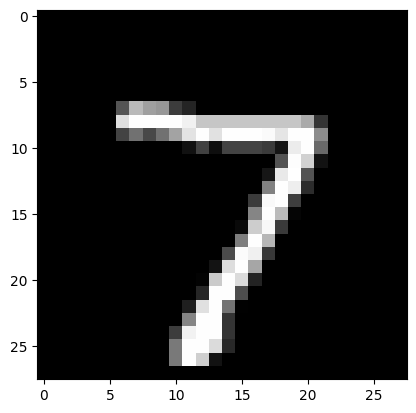

In [ ]:
prediction = model.predict(X_test[:1])

print("Predicted Digit:", np.argmax(prediction))
print("Actual Digit:", np.argmax(y_test[0]))

plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.show()

**RNN**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (18).zip to archive (18).zip


In [ ]:
df = pd.read_csv(list(uploaded.keys())[0])

print(df.head())
print(df.columns)


                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Index(['review', 'sentiment'], dtype='object')


In [ ]:
le = LabelEncoder()
target = le.fit_transform(df['sentiment']).reshape(-1, 1)

In [ ]:
scaler = MinMaxScaler()
target_scaled = scaler.fit_transform(target)

In [ ]:
X = []
y = []

time_steps = 10

for i in range(time_steps, len(target_scaled)):
    X.append(target_scaled[i-time_steps:i, 0])
    y.append(target_scaled[i, 0])

X = np.array(X)
y = np.array(y)

In [ ]:
X = X.reshape((X.shape[0], X.shape[1], 1))

print("X Shape:", X.shape)
print("y Shape:", y.shape)


X Shape: (49990, 10, 1)
y Shape: (49990,)


In [ ]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
model = Sequential()

model.add(
    SimpleRNN(
        units=50,
        activation='tanh',
        input_shape=(X_train.shape[1],1)
    )
)

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test)
)


Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2564 - mae: 0.5000 - val_loss: 0.2510 - val_mae: 0.4999
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2531 - mae: 0.4999 - val_loss: 0.2510 - val_mae: 0.4993
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2528 - mae: 0.5000 - val_loss: 0.2499 - val_mae: 0.4998
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2520 - mae: 0.5002 - val_loss: 0.2502 - val_mae: 0.4999
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.2519 - mae: 0.5001 - val_loss: 0.2513 - val_mae: 0.5002
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2512 - mae: 0.4997 - val_loss: 0.2508 - val_mae: 0.4996
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2515 - mae: 0.5003 - val_loss: 0.2502 - val_mae: 0.4999
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.2509 - mae: 0.4999 - val_loss: 0.2507 - val_mae: 0.5000
Epoch 9/20
1250/1250 ━━━━━━━━━━━━━━━━━━━

In [ ]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
actual = scaler.inverse_transform(y_test.reshape(-1,1))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


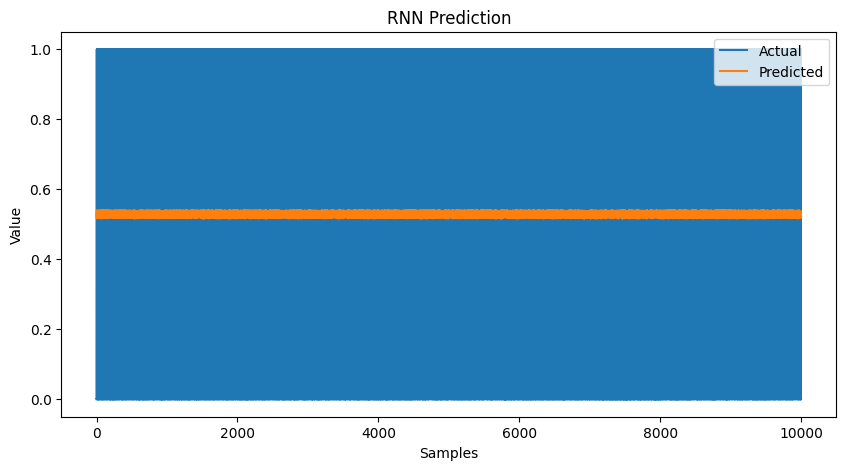

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(actual, label='Actual')

plt.plot(predictions, label='Predicted')

plt.title("RNN Prediction")
plt.xlabel("Samples")
plt.ylabel("Value")
plt.legend()

plt.show()

In [ ]:
loss, mae = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("MAE:", mae)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2508 - mae: 0.5000
Loss: 0.2508194148540497
MAE: 0.49995335936546326


**LSTM**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (19).zip to archive (19).zip


In [ ]:
import zipfile
import io

file_name = list(uploaded.keys())[0]

with zipfile.ZipFile(file_name, 'r') as z:
    with z.open('train.csv') as f:
        df = pd.read_csv(io.TextIOWrapper(f, 'utf-8'))

print(df.head())
print(df.columns)

   Unnamed: 0      id  Gender      Customer Type  Age   Type of Travel  \
0           0   70172    Male     Loyal Customer   13  Personal Travel   
1           1    5047    Male  disloyal Customer   25  Business travel   
2           2  110028  Female     Loyal Customer   26  Business travel   
3           3   24026  Female     Loyal Customer   25  Business travel   
4           4  119299    Male     Loyal Customer   61  Business travel   

      Class  Flight Distance  Inflight wifi service  \
0  Eco Plus              460                      3   
1  Business              235                      3   
2  Business             1142                      2   
3  Business              562                      2   
4  Business              214                      3   

   Departure/Arrival time convenient  ...  Inflight entertainment  \
0                                  4  ...                       5   
1                                  2  ...                       1   
2                

In [ ]:
ata = df.select_dtypes(include=np.number)

In [ ]:
ata = df.select_dtypes(include=np.number)

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
dataset = scaler.fit_transform(ata)

In [ ]:
X = []
y = []

time_step = 10

for i in range(time_step, len(dataset)):
    X.append(dataset[i-time_step:i, 0])
    y.append(dataset[i, 0])

X = np.array(X)
y = np.array(y)


In [ ]:
X = X.reshape(X.shape[0], X.shape[1], 1)

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (103894, 10, 1)
Y Shape: (103894,)


In [ ]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
model = Sequential()

model.add(
    LSTM(
        units=50,
        return_sequences=False,
        input_shape=(X_train.shape[1],1)
    )
)

model.add(Dense(1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.0011 - val_loss: 1.6829e-04
Epoch 2/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 1.7362e-06 - val_loss: 5.1460e-05
Epoch 3/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 9.9860e-07 - val_loss: 2.7243e-07
Epoch 4/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 1.5724e-06 - val_loss: 4.0810e-07
Epoch 5/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 1.0351e-06 - val_loss: 1.2819e-06
Epoch 6/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 1.0005e-06 - val_loss: 6.9348e-07
Epoch 7/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 1.0871e-06 - val_loss: 7.9984e-07
Epoch 8/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 1.0136e-06 - val_loss: 1.9078e-06
Epoch 9/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 7.0801e-07 - val_loss: 2.9964e-06
Epoch 10/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 1.1017e-06 - val_loss: 2.0650e-06
Epoch 11/20
2598/2598 ━━━━━━━━━━━

In [ ]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test.reshape(-1,1))

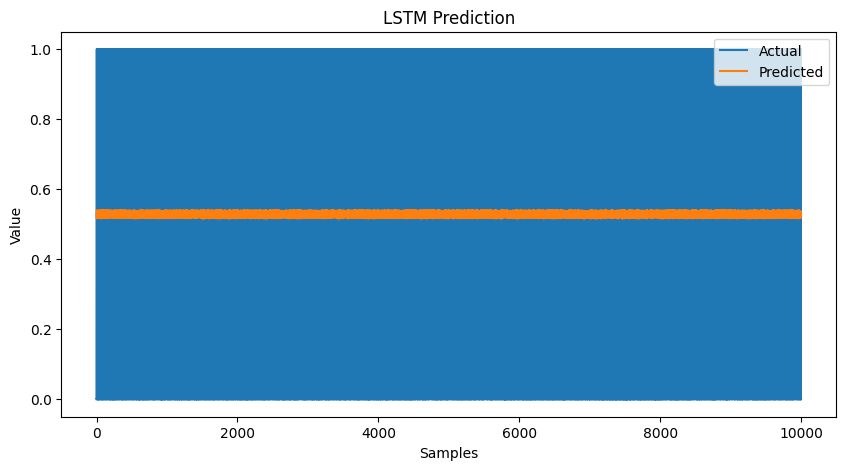

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(actual, label="Actual")
plt.plot(predictions, label="Predicted")

plt.title("LSTM Prediction")
plt.xlabel("Samples")
plt.ylabel("Value")
plt.legend()

plt.show()


In [ ]:
loss = model.evaluate(X_test, y_test)

print("Loss:", loss)

650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.0934e-06
Loss: 2.09339486900717e-06


**GRU**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving archive (20).zip to archive (20).zip


In [ ]:
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print(df.head())
print(df.columns)

   Temperature   Humidity  Wind_Speed  Cloud_Cover     Pressure     Rain
0    23.720338  89.592641    7.335604    50.501694  1032.378759     rain
1    27.879734  46.489704    5.952484     4.990053   992.614190  no rain
2    25.069084  83.072843    1.371992    14.855784  1007.231620  no rain
3    23.622080  74.367758    7.050551    67.255282   982.632013     rain
4    20.591370  96.858822    4.643921    47.676444   980.825142  no rain
Index(['Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure',
       'Rain'],
      dtype='object')


In [ ]:
data = df.select_dtypes(include=np.number)

In [ ]:
dataset = data.iloc[:, -1].values.reshape(-1,1)


In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
dataset = scaler.fit_transform(dataset)

In [ ]:
X = []
y = []

time_step = 10

for i in range(time_step, len(dataset)):
    X.append(dataset[i-time_step:i, 0])
    y.append(dataset[i, 0])

X = np.array(X)
y = np.array(y)

In [ ]:
X = X.reshape(X.shape[0], X.shape[1], 1)

print("X Shape:", X.shape)
print("Y Shape:", y.shape)


X Shape: (2490, 10, 1)
Y Shape: (2490,)


In [ ]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
model = Sequential()

model.add(
    GRU(
        units=50,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0991 - val_loss: 0.0906
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0857 - val_loss: 0.0896
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0854 - val_loss: 0.0871
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0834 - val_loss: 0.0869
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0837 - val_loss: 0.0873
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0832 - val_loss: 0.0858
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0835 - val_loss: 0.0858
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0833 - val_loss: 0.0873
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0830 - val_loss: 0.0857
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0838 - val_loss: 0.0859
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0830 - val_loss: 0.0873
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0831 - val_l

In [ ]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test.reshape(-1,1))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


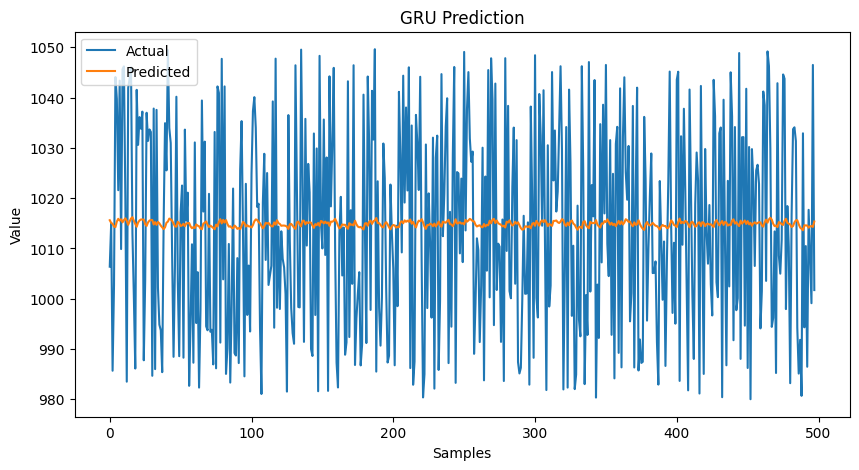

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(actual, label="Actual")
plt.plot(predictions, label="Predicted")

plt.title("GRU Prediction")
plt.xlabel("Samples")
plt.ylabel("Value")
plt.legend()

plt.show()


In [ ]:
loss = model.evaluate(X_test, y_test)

print("Loss:", loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0860
Loss: 0.08595548570156097
